# TF-IDF + MLP

In [10]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

sys.path.append('..')
from src.text_processing import CustomTFIDF
from src.data_utils import stratified_split, build_label_maps, encode_labels, create_tfidf_features, make_dataloaders_from_arrays
from src.pytorch_models import MLPClassifier, select_device
from src.train_utils import set_seed, run_training, evaluate, compute_metrics

set_seed(2026)
device = select_device()
print('Device:', device)

CLASS_ORDER = ['Human', 'Google', 'Meta', 'OpenAI', 'Anthropic']

TRAIN_FRACTION = 1.0
MAX_FEATURES   = 2000
HIDDEN_DIM     = 256
DROPOUT        = 0.3
BATCH_SIZE     = 256
LR             = 1e-3
EPOCHS         = 50
PATIENCE       = 5

Device: cpu


## Dados

In [11]:
#df = pd.read_csv('../data/clean_datasets/dataset_clean_final.csv')
df = pd.read_csv('../data/domain_treated_datasets/dataset_final_domains.csv')
train_df, val_df = stratified_split(df, 'text', 'label', test_size=0.2, seed=2026)

if TRAIN_FRACTION < 1.0:
    train_df = train_df.groupby('label', group_keys=False).apply(
        lambda g: g.sample(frac=TRAIN_FRACTION, random_state=2026)
    ).reset_index(drop=True)

test_df = pd.read_csv('../data/subm1_labels_revealed.csv', sep=';')
test_df = test_df.rename(columns={'Text': 'text', 'Label': 'label'})

print(f'Treino: {len(train_df):,} | Validação: {len(val_df):,} | Teste (prof): {len(test_df)}')

label_to_idx, idx_to_label = build_label_maps(CLASS_ORDER)
y_train = encode_labels(train_df['label'], label_to_idx)
y_val   = encode_labels(val_df['label'],   label_to_idx)
y_test  = encode_labels(test_df['label'],  label_to_idx)

Treino: 56,000 | Validação: 14,000 | Teste (prof): 100


## Features TF-IDF

In [12]:
tfidf, X_train, X_val = create_tfidf_features(train_df['text'], val_df['text'], max_features=MAX_FEATURES)
X_test = tfidf.transform(test_df['text'].values).astype(np.float32)

train_loader, val_loader = make_dataloaders_from_arrays(X_train, y_train, X_val, y_val, BATCH_SIZE)
from torch.utils.data import TensorDataset, DataLoader
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=BATCH_SIZE, shuffle=False
)
print(f'TF-IDF features: {X_train.shape[1]}')

Vocabulário criado com 2000 palavras
TF-IDF features: 2000


## Modelo

In [13]:
model = MLPClassifier(
    input_size=MAX_FEATURES,
    hidden_size=HIDDEN_DIM,
    num_classes=len(CLASS_ORDER),
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nParâmetros totais: {total_params:,}')

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=2000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=5, bias=True)
  )
)

Parâmetros totais: 513,541


## Treino

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

mlflow_params = {
    'model': 'MLP_TFIDF',
    'max_features': MAX_FEATURES,
    'hidden_dim': HIDDEN_DIM,
    'dropout': DROPOUT,
    'lr': LR,
    'batch_size': BATCH_SIZE,
    'train_fraction': TRAIN_FRACTION,
}

history, best_state, best_epoch = run_training(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=EPOCHS, patience=PATIENCE, verbose=True,
    mlflow_params=mlflow_params,
)

model.load_state_dict(best_state)
print(f'\nMelhor epoch: {best_epoch}')

Epoch 01/50 | train_loss=1.0208 train_acc=0.7369 | val_loss=0.5552 val_acc=0.8489
Epoch 02/50 | train_loss=0.4290 train_acc=0.8698 | val_loss=0.3549 val_acc=0.8863
Epoch 03/50 | train_loss=0.3088 train_acc=0.8944 | val_loss=0.2973 val_acc=0.8950
Epoch 04/50 | train_loss=0.2635 train_acc=0.9057 | val_loss=0.2758 val_acc=0.8989
Epoch 05/50 | train_loss=0.2394 train_acc=0.9130 | val_loss=0.2667 val_acc=0.8999
Epoch 06/50 | train_loss=0.2220 train_acc=0.9187 | val_loss=0.2610 val_acc=0.9034
Epoch 07/50 | train_loss=0.2095 train_acc=0.9223 | val_loss=0.2589 val_acc=0.9024
Epoch 08/50 | train_loss=0.2004 train_acc=0.9263 | val_loss=0.2579 val_acc=0.9015
Epoch 09/50 | train_loss=0.1926 train_acc=0.9284 | val_loss=0.2593 val_acc=0.9019
Epoch 10/50 | train_loss=0.1852 train_acc=0.9305 | val_loss=0.2599 val_acc=0.9028
Epoch 11/50 | train_loss=0.1778 train_acc=0.9334 | val_loss=0.2620 val_acc=0.9024
Early stopping at epoch 11 (best epoch=6, best val_acc=0.9034)

Melhor epoch: 6


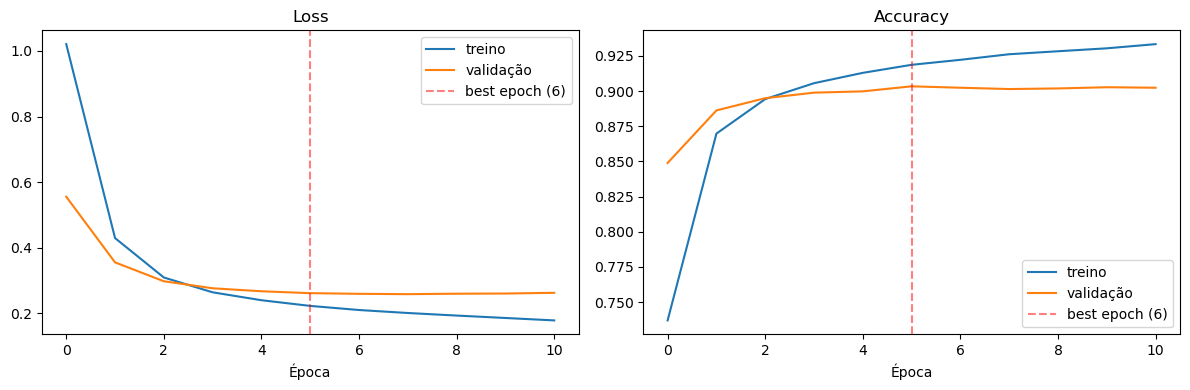

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (tr, vl, title) in zip(axes, [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_acc',  'val_acc',  'Accuracy'),
]):
    ax.plot(history[tr], label='treino')
    ax.plot(history[vl], label='validação')
    ax.axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best epoch ({best_epoch})')
    ax.set_xlabel('Época')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

## Avaliação

In [16]:
for loader, name in [(val_loader, 'Validação (20%)'), (test_loader, 'Teste (prof)')]:
    _, _, y_true, y_pred = evaluate(model, loader, criterion, device)
    m = compute_metrics(y_true, y_pred, list(range(len(CLASS_ORDER))))
    print(f'\n=== {name} ===')
    print(f'Accuracy: {m["accuracy"]:.4f} | Macro F1: {m["macro_f1"]:.4f}')
    print(m['report'])


=== Validação (20%) ===
Accuracy: 0.9034 | Macro F1: 0.9034
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2800
           1       0.86      0.88      0.87      2800
           2       0.89      0.86      0.87      2800
           3       0.92      0.92      0.92      2800
           4       0.93      0.94      0.93      2800

    accuracy                           0.90     14000
   macro avg       0.90      0.90      0.90     14000
weighted avg       0.90      0.90      0.90     14000


=== Teste (prof) ===
Accuracy: 0.4000 | Macro F1: 0.3492
              precision    recall  f1-score   support

           0       0.84      0.62      0.71        34
           1       0.33      0.24      0.28        17
           2       1.00      0.11      0.20        18
           3       0.18      0.36      0.24        14
           4       0.24      0.47      0.32        17

    accuracy                           0.40       100
   macro avg

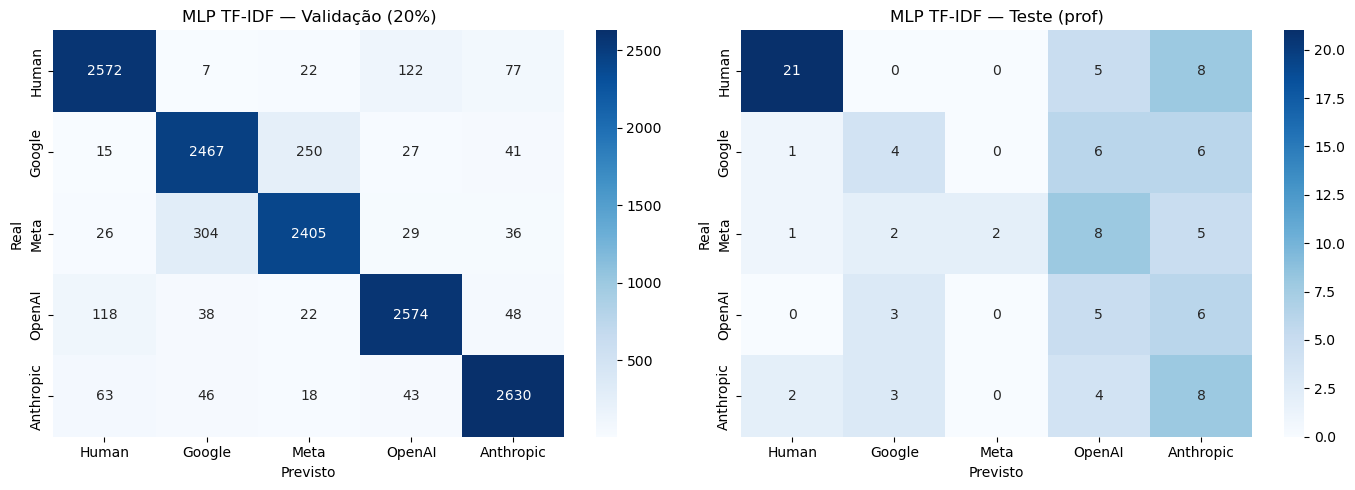

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (loader, name) in zip(axes, [(val_loader, 'Validação (20%)'), (test_loader, 'Teste (prof)')]):
    _, _, y_true, y_pred = evaluate(model, loader, criterion, device)
    m = compute_metrics(y_true, y_pred, list(range(len(CLASS_ORDER))))
    sns.heatmap(m['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_title(f'MLP TF-IDF — {name}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

## Guardar

In [ ]:
import os, pickle
os.makedirs('../modelos', exist_ok=True)

torch.save(best_state, '../modelos/mlp_tfidf.pt')
with open('../modelos/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('Guardado em ../modelos/mlp_tfidf.pt e ../modelos/tfidf_vectorizer.pkl')